In [1]:
from datetime import datetime
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.ticker as mtick
import seaborn as sns
import requests
import time
import re
from bootstrap_mc_kalshi import load_and_prepare, build_player_pool, build_player_pool_score, run_simulation, run_simulation_score, build_results, USERNAME_TO_PLAYER, PLAYER_TO_USERNAMES

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
pd.set_option({
    'display.max_rows':300,
    'display.max_columns':300,
    'display.max_colwidth':300
})

df_tourneys = pd.read_csv("data/titled_tuesday_tournaments.csv")
df_standings = pd.read_csv("data/titled_tuesday_standings_modern.csv")
df_tourneys = df_tourneys[df_tourneys["date"]>"2022-02-01"]
df_standings = df_standings[df_standings["date"]>"2022-02-01"]

CUT_PLAYERS = ['Magnus Carlsen']
KEEP_PLAYERS = ['Hikaru Nakamura']
N_SIMS = 50_000


df, p_participate, app_counts = load_and_prepare(CUT_PLAYERS, KEEP_PLAYERS, attendance_model='gradient_boost')
players, p_play, hist_pcts, hist_wts = build_player_pool_score(
    df, p_participate, app_counts, min_appearances=0
)

print(f'Pool: {len(players):,} players | simulating {N_SIMS:,} tournaments...')
plays_ct, topn_ct = run_simulation_score(players, p_play, hist_pcts, hist_wts, n_sims = N_SIMS)
results = build_results(players, p_play, plays_ct, topn_ct, n_sims= N_SIMS)

BASE = "https://api.elections.kalshi.com/trade-api/v2"
event_tickers = ["KXTITLEDTUESDAY-26JUL14","KXTITLEDTUESTOP-26JUL14T3","KXTITLEDTUESTOP-26JUL14T8"]


markets = []
cursor = None
for event_ticker in event_tickers:
    while True:
        params = {"event_ticker": event_ticker, "status": "open", "limit": 200}
        if cursor:
            params["cursor"] = cursor
        resp = requests.get(f"{BASE}/markets", params=params)
        resp.raise_for_status()
        data = resp.json()
        markets.extend(data.get("markets", []))
        cursor = data.get("cursor")
        if not cursor:
            break

all_asks= []

if markets:
    print(f"Found {len(markets)} markets in events '{[event_ticker for event_ticker in event_tickers]}'. Fetching rates...")

    for market in markets:
        ticker = market["ticker"]
        title = market.get("title", "")
        subtitle = market.get("yes_sub_title", "")

        ob_resp = requests.get(f"{BASE}/markets/{ticker}/orderbook")

        if ob_resp.status_code == 200:
            ob = ob_resp.json().get("orderbook_fp") or {}
            # Resting NO bids: each [price, qty] NO bid implies
            # YES is for sale at (1.00 - no_price) for that quantity.
            yes_levels = ob.get("yes_dollars") or []
            no_levels = ob.get("no_dollars") or []

            for price_str, qty_str in yes_levels:
                no_ask = float("1.00") - float(price_str)
                all_asks.append({
                    "Market Ticker": ticker,
                    "Market Title": title,
                    "Player Name": subtitle,
                    "Ask Price ($)": float(no_ask),
                    "Quantity Available": float(qty_str),
                    "Side": "NO"
                })
            for price_str, qty_str in no_levels:
                yes_ask = float("1.00") - float(price_str)
                all_asks.append({
                    "Market Ticker": ticker,
                    "Market Title": title,
                    "Player Name": subtitle,
                    "Ask Price ($)": float(yes_ask),
                    "Quantity Available": float(qty_str),
                    "Side": "YES"
                })
        else:
            print(f"Could not retrieve orderbook for {ticker} "
                  f"(HTTP {ob_resp.status_code})")

        time.sleep(0.05)  # stay under public rate limits


def kalshi_order_price(ask_price):
    return ask_price + (0.07 * ask_price * (1.0 - ask_price))

df = pd.DataFrame(all_asks)
df['n'] = df['Market Title'].apply(lambda s: re.search(r'\d+',s).group())

df['username'] = df['Player Name'].apply(lambda n: PLAYER_TO_USERNAMES[n][0])
evs = []
order_prices=[]
for _, row in df.iterrows():
    n = 1 if row['n'] == '14' else int(row['n'])
    if row['username']=='MagnusCarlsen':
        evs.append(0 if row['Side']=='YES' else 1)
    else:
        p_yes = (results.loc[row['username'], f'P_top{n}'].item())
        evs.append(p_yes if row['Side']=='YES' else (1-p_yes))

df['EV'] = evs
df['Order Price'] = (df['Ask Price ($)'] + 0.07 * df['Ask Price ($)'] * (1.0 - df['Ask Price ($)']))
df['Total Cost'] = df['Quantity Available']*df['Order Price']
df['Expected Return'] = ((df['EV']-df['Order Price'])*df['Quantity Available'].astype(int))
df['ROI'] = round(df['EV']/df['Order Price'].astype(float),3)
df[['Market Title','ROI','Side','Order Price','EV','Quantity Available','Total Cost','Expected Return']][df['ROI']>1].sort_values('ROI',ascending=False)


  Loaded models\attendance_gradient_boost.pkl  (CV: {'auc': 0.8024, 'brier': 0.1491, 'log_loss': 0.463})
  Loaded models\attendance_logistic.pkl  (CV: {'auc': 0.7938, 'brier': 0.1785, 'log_loss': 0.5383})
  Loaded models\attendance_random_forest.pkl  (CV: {'auc': 0.8031, 'brier': 0.1757, 'log_loss': 0.5302})
  p_participate: gradient_boost model (6,780 players, 2,037 EWMA fallback)
  230 events | 8,817 unique players | 2022-02-08 to 2026-07-07
  Player pool: 8,817
Pool: 8,817 players | simulating 50,000 tournaments...
Found 153 markets in events '['KXTITLEDTUESDAY-26JUL14', 'KXTITLEDTUESTOP-26JUL14T3', 'KXTITLEDTUESTOP-26JUL14T8']'. Fetching rates...


,Market Title,ROI,Side,Order Price,EV,Quantity Available,Total Cost,Expected Return
783,"Will Jose Martinez finish top 3 in the Titled Tuesday chess competition on Jul 14, 2026?",1.247,YES,0.063948,0.07972,1.00,0.063948,0.015772
1012,"Will Wesley So finish top 8 in the Titled Tuesday chess competition on Jul 14, 2026?",1.230,YES,0.085152,0.10474,5.00,0.425760,0.097940
1346,"Will Fabiano Caruana finish top 8 in the Titled Tuesday chess competition on Jul 14, 2026?",1.218,NO,0.636492,0.77546,5.00,3.182460,0.694840
1345,"Will Fabiano Caruana finish top 8 in the Titled Tuesday chess competition on Jul 14, 2026?",1.200,NO,0.646317,0.77546,100.18,64.748037,12.914300
1344,"Will Fabiano Caruana finish top 8 in the Titled Tuesday chess competition on Jul 14, 2026?",1.164,NO,0.665925,0.77546,200.00,133.185000,21.907000
1205,"Will Matthias Bluebaum finish top 8 in the Titled Tuesday chess competition on Jul 14, 2026?",1.138,YES,0.116853,0.13298,277.00,32.368281,4.467179
1166,"Will Nodirbek Abdusattorov finish top 8 in the Titled Tuesday chess competition on Jul 14, 2026?",1.113,NO,0.849408,0.94498,100.00,84.940800,9.557200
856,"Will Fabiano Caruana finish top 3 in the Titled Tuesday chess competition on Jul 14, 2026?",1.112,NO,0.830332,0.92322,100.00,83.033200,9.288800
1165,"Will Nodirbek Abdusattorov finish top 8 in the Titled Tuesday chess competition on Jul 14, 2026?",1.100,NO,0.858925,0.94498,200.00,171.785000,17.211000
855,"Will Fabiano Caruana finish top 3 in the Titled Tuesday chess competition on Jul 14, 2026?",1.099,NO,0.839877,0.92322,200.00,167.975400,16.668600


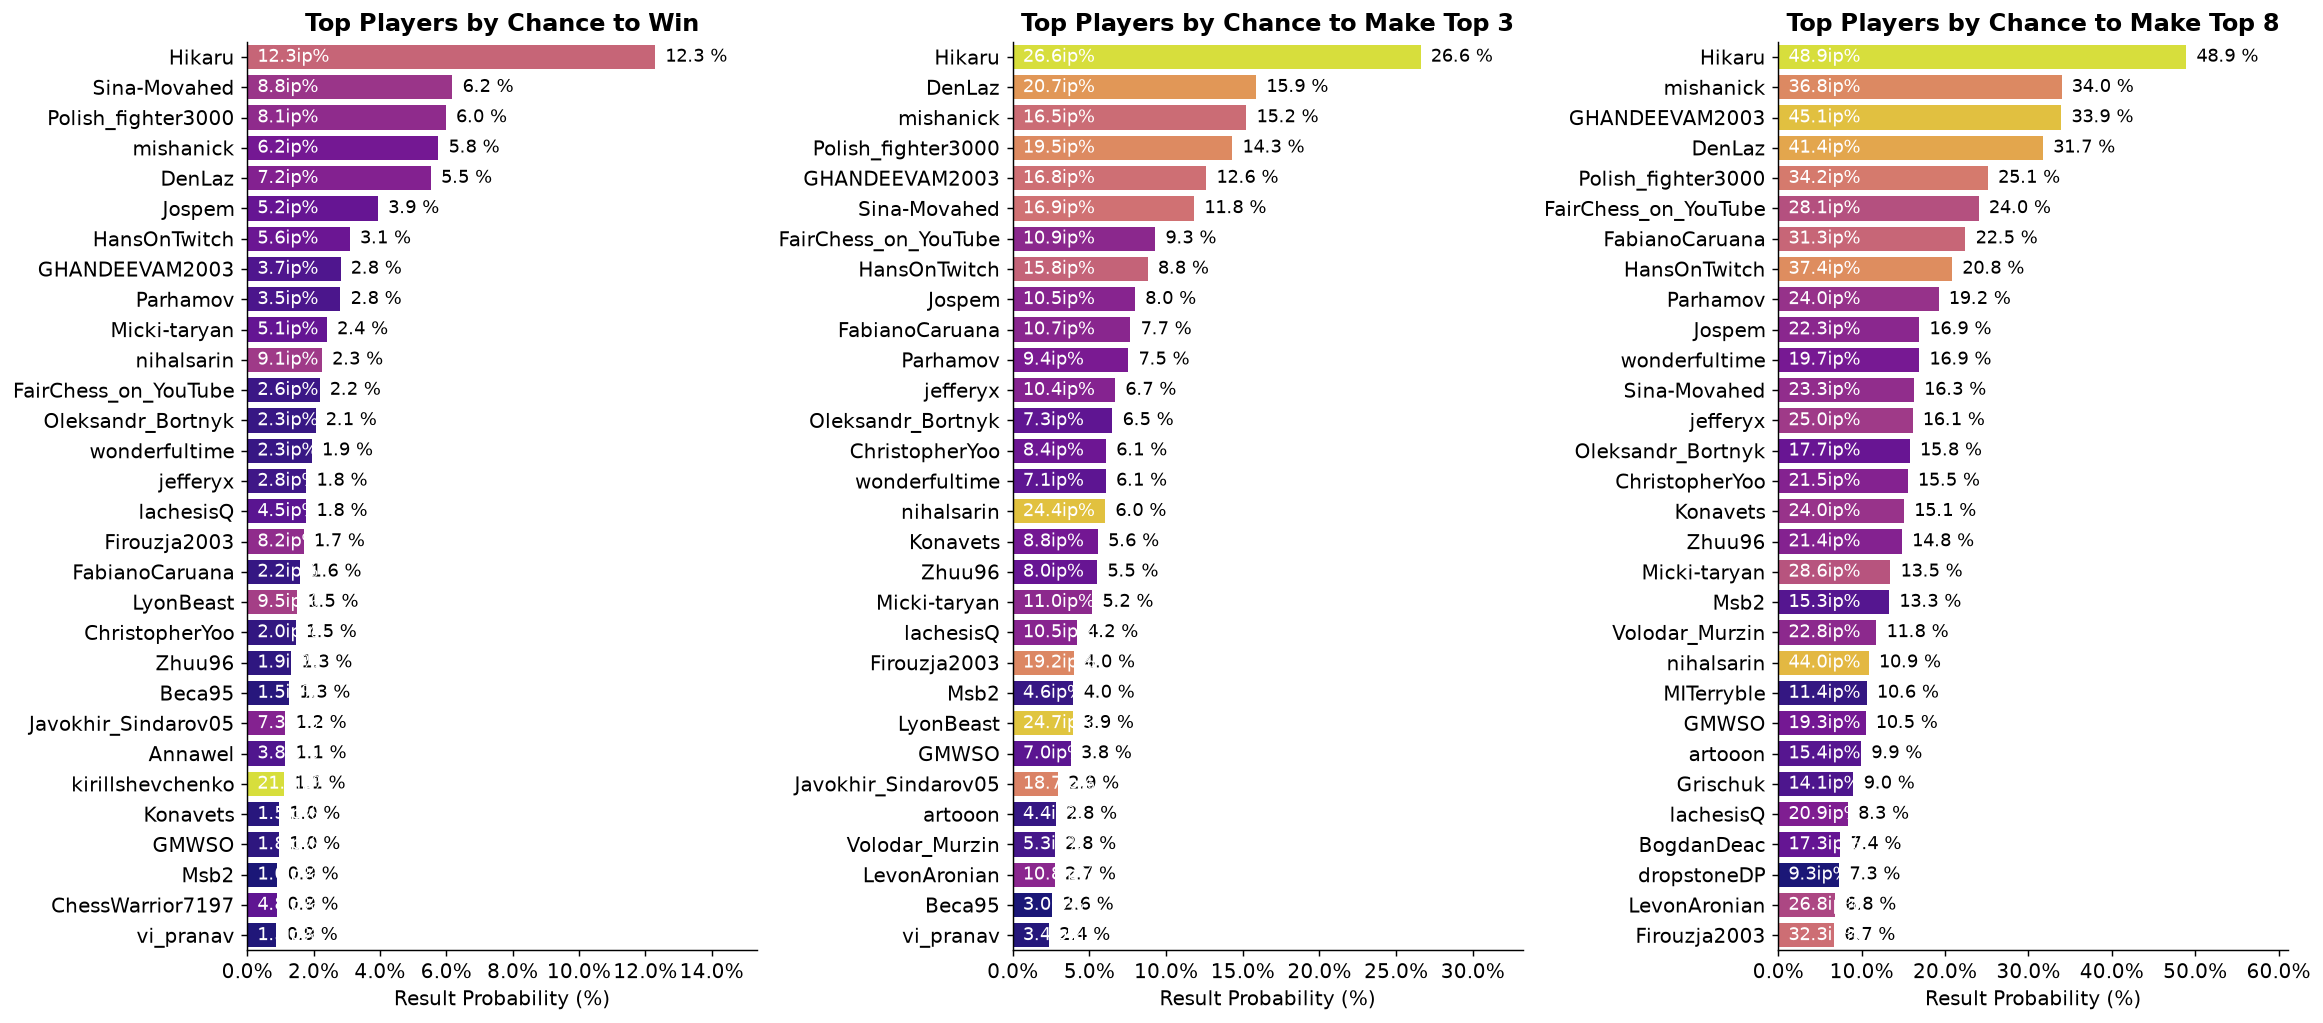

In [3]:
fig, axes = plt.subplots(1,3, figsize=(18,8))

metrics = [
    (1,'Top Players by Chance to Win'),
    (3,'Top Players by Chance to Make Top 3'),
    (8,'Top Players by Chance to Make Top 8'),
]

cmap = plt.get_cmap('plasma')

for ax, (n, title) in zip(axes, metrics):

    col_chance = f'P_top{n}'
    col_when = f'P_top{n}_given_play'

    df_plot = results.nlargest(30,col_chance).reset_index()

    norm = mcolors.Normalize(vmin=df_plot[col_when].min(), vmax=df_plot[col_when].max())
    colors = cmap(norm(df_plot[col_when]))

    sns.barplot(data = df_plot, x=col_chance, y='username', ax=ax, palette=colors)

    ax.set_title(title, fontweight='bold')

    max_width = df_plot[col_chance].max()*1.25
    ax.set_xlim(0, max_width)
    ax.set_xlabel('Result Probability (%)')
    ax.set_ylabel('')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))

    for i, p in enumerate(ax.patches):
        width = p.get_width()
        y = p.get_y() + p.get_height()/2
        
        chance_val = df_plot.iloc[i][col_chance]
        when_val = df_plot.iloc[i][col_when]

        ax.text(width + (max_width * 0.02), y, f'{chance_val*100:.1f} %', va = 'center', ha='left', fontsize=10, color='black')
        ax.text(max_width * 0.02, y, f'{when_val*100:.1f}ip%', va = 'center', ha='left', fontsize=10, color='white')

plt.tight_layout()
plt.show()

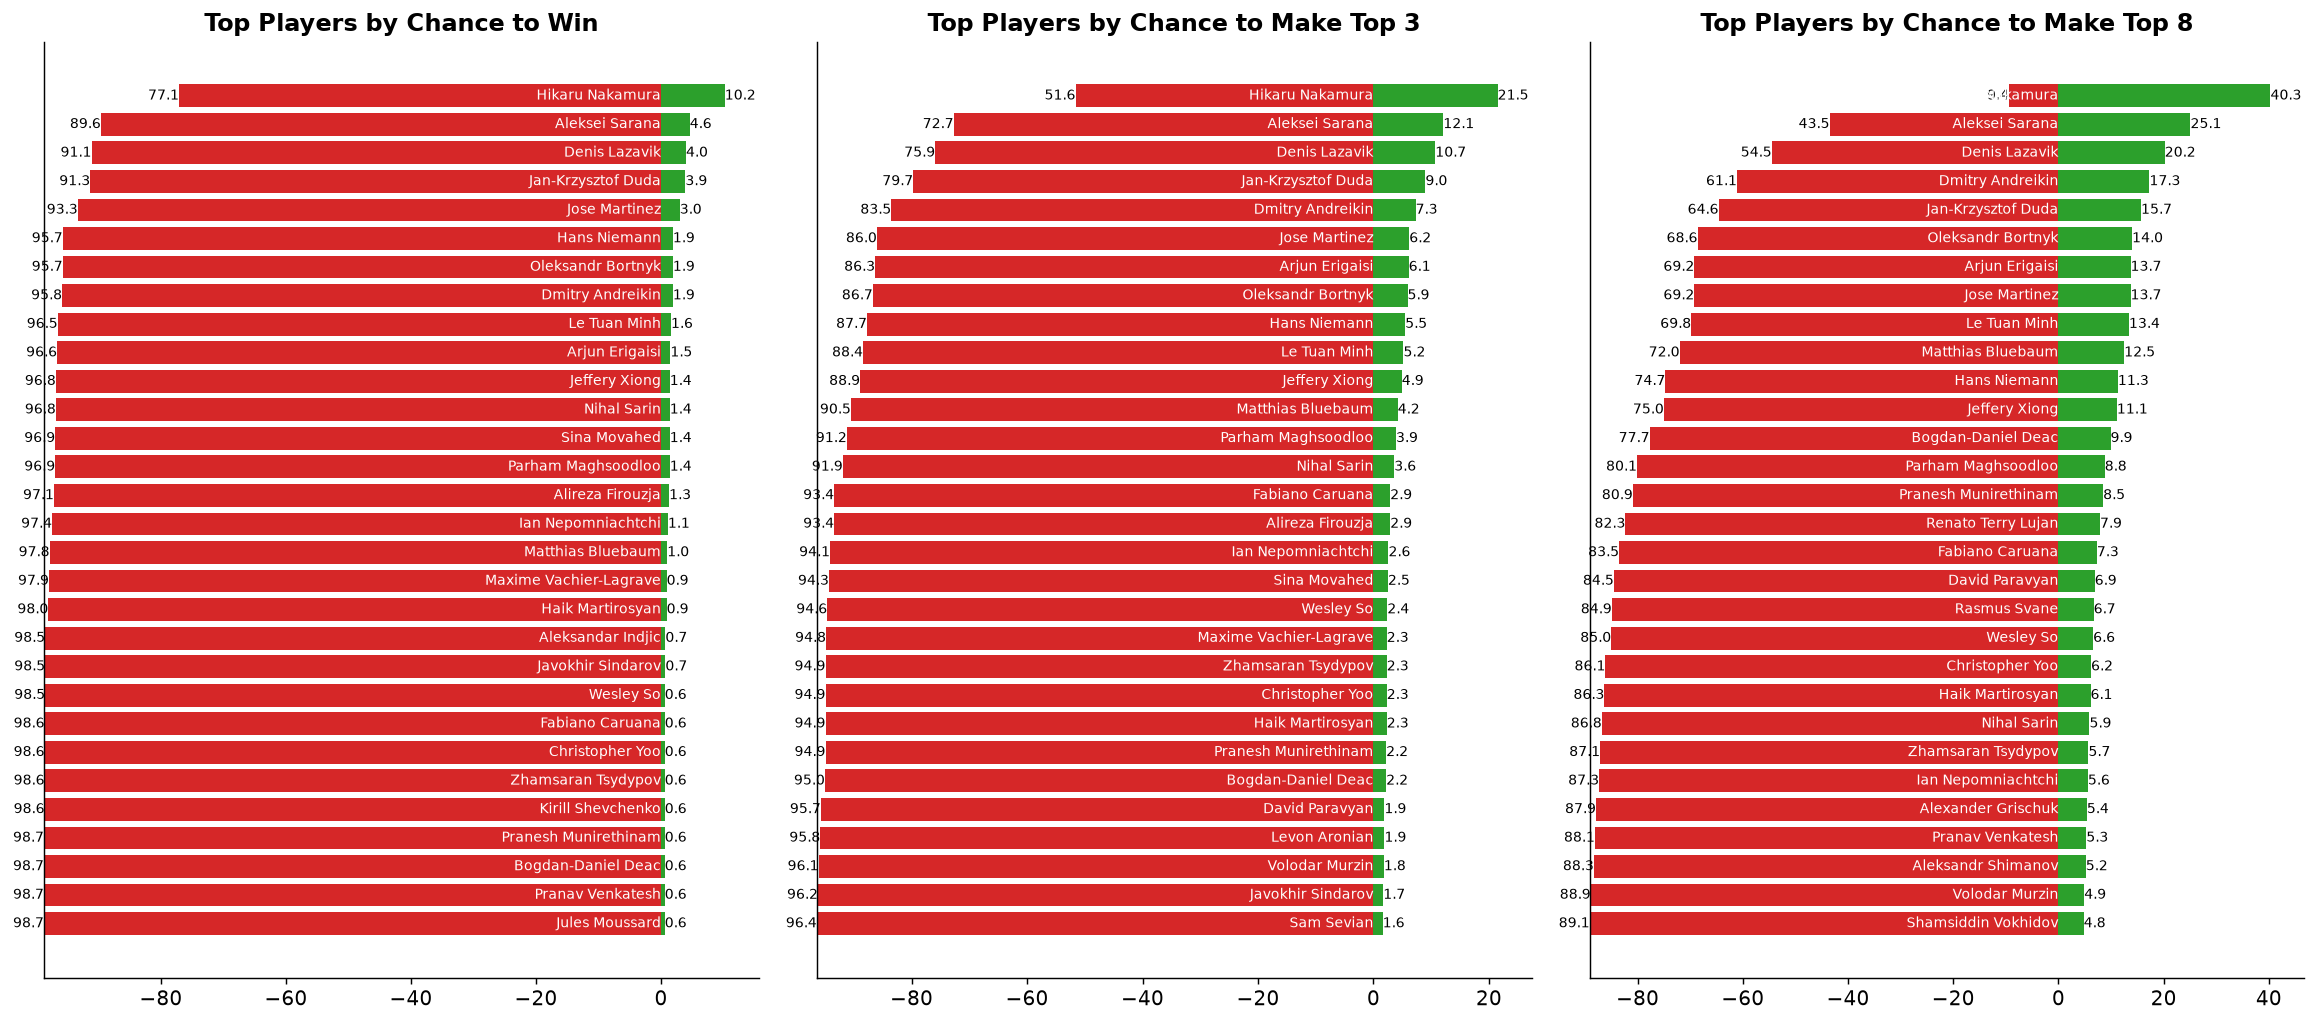

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18,8))

metrics = [
    (1,'Top Players by Chance to Win'),
    (3,'Top Players by Chance to Make Top 3'),
    (8,'Top Players by Chance to Make Top 8'),
]

cmap = plt.get_cmap('plasma')

for ax, (n, title) in zip(axes, metrics):

    col_chance = f'P_top{n}'
    col_when = f'P_top{n}_given_play'

    df_plot = results.nlargest(30,col_chance).reset_index()

    # Calculate Kalshi Yes and No prices
    # Using np.clip to ensure the No price doesn't drop below $0.00 if the estimate is very high (>75%)
    df_plot['Yes_Price'] = np.round(df_plot[col_chance] * (2/3) * 100, 1)
    df_plot['No_Price'] = np.round((1-df_plot[col_chance] * (3/2))*100, 1)

    # --- Plot YES Bars ---
    ax.barh(df_plot.index, df_plot['Yes_Price'], height=0.8, color='#2ca02c', label='Yes Price')

    # --- Plot NO Bars ---
    ax.barh(df_plot.index, df_plot['No_Price'], left=-df_plot['No_Price'], height=0.8, color='#d62728', label='No Price')

    # Set the Y-axis labels to the Yes Price
    ax.set_yticks([])
    ax.invert_yaxis()  # Put the highest chance player at the top
    ax.set_title(title, fontweight='bold')

    
    # Add data labels dynamically
    for i, row in df_plot.iterrows():
        yes_val = row['Yes_Price']
        no_val = row['No_Price']
        name = USERNAME_TO_PLAYER[row['username']]
        
        # Text for the Yes price (placed slightly to the right of the green bar's edge)
        ax.text(yes_val, i, yes_val, va='center', ha='left', fontsize=8, color='black')
        
        # Text for the No price (placed slightly to the left of the red bar's edge)
        # The inner edge of the red bar is exactly at (1 - no_val)
        ax.text(-no_val, i, no_val, va='center', ha='right', fontsize=8, color='black')

        ax.text(0, i, name, va='center', ha='right', fontsize=8, color='white')



plt.tight_layout()
plt.show()

garcho08 ?
GukeshDommaraju ?
gurelediz ?
Grandelicious ?
Alexander_Zubov ?
PursuitOfHappyness2 ?
garcho08 ?
Masmos97 ?
KantorGergely ?
rednova1729 ?
chesspanda123 ?
GukeshDommaraju ?
SpeedofLight0 ?
AnishGiri ?
champ2005 ?
xiaotong2008 ?
Philippians46 ?
gurelediz ?


findfont: Failed to find font weight heavy, now using 700.


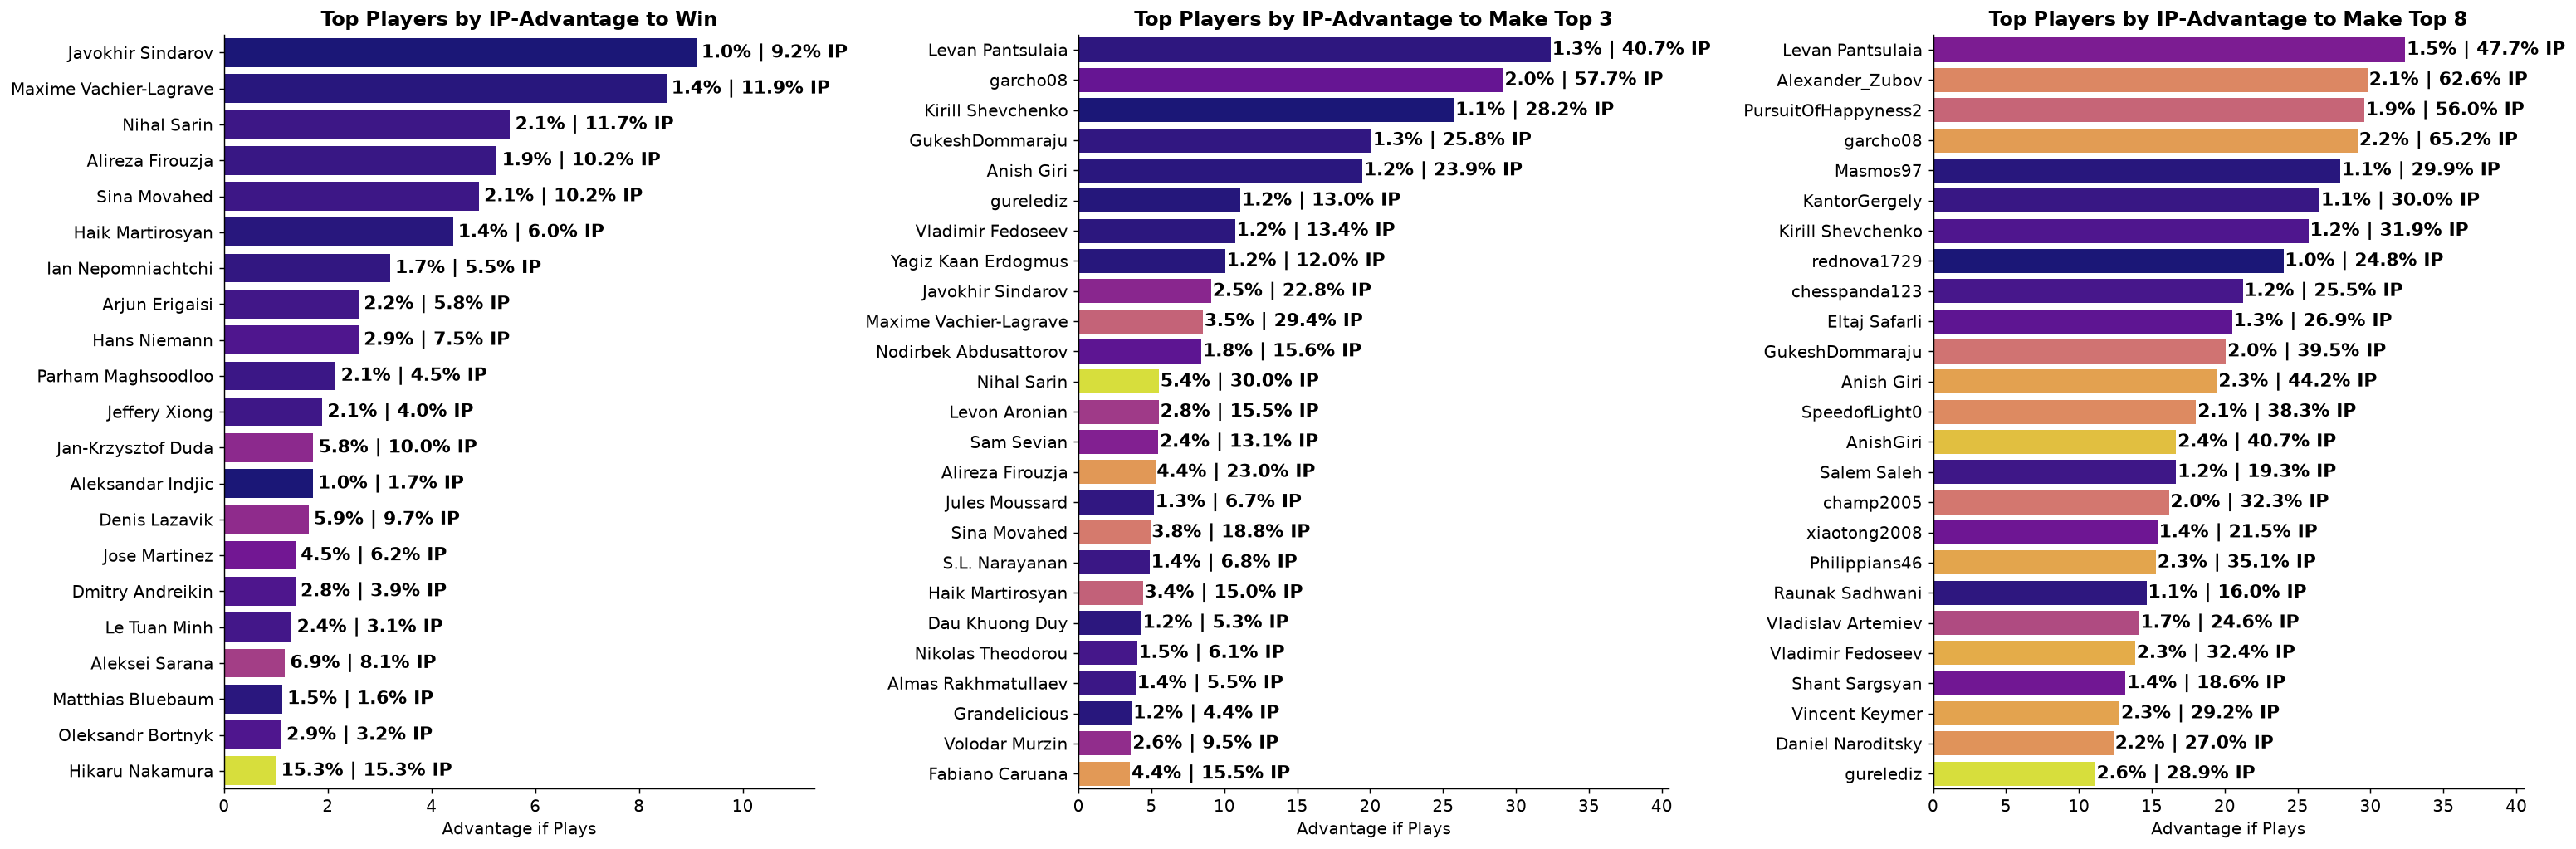

In [4]:
fig, axes = plt.subplots(1,3, figsize=(24,8))

metrics = [
    (1,'Top Players by IP-Advantage to Win'),
    (3,'Top Players by IP-Advantage to Make Top 3'),
    (8,'Top Players by IP-Advantage to Make Top 8'),
]

cmap = plt.get_cmap('plasma')

for ax, (n, title) in zip(axes, metrics):

    col_when = f'P_top{n}'
    col_chance = f'P_top{n}_given_play'
    ip_adv = f'ip_adv_top{n}'

    df_plot = results[results[col_when]>.01].nlargest(25,ip_adv).reset_index()

    def get_name(username):
        try:
            return USERNAME_TO_PLAYER[username]
        except:
            print(username, "?")
            return username
    df_plot['name'] = df_plot['username'].apply(get_name)

    norm = mcolors.Normalize(vmin=df_plot[col_when].min(), vmax=df_plot[col_when].max())
    colors = cmap(norm(df_plot[col_when]))

    sns.barplot(data = df_plot, x=ip_adv, y='name', ax=ax, palette=colors)

    ax.set_title(title, fontweight='bold')

    max_width = df_plot[ip_adv].max()*1.25
    ax.set_xlim(0, max_width)
    ax.set_xlabel('Advantage if Plays')
    ax.set_ylabel('')

    for i, p in enumerate(ax.patches):
        width = p.get_width()
        y = p.get_y() + p.get_height()/2
        
        chance_val = df_plot.iloc[i][col_chance]
        when_val = df_plot.iloc[i][col_when]
        adv_val = df_plot.iloc[i][ip_adv]
        name = df_plot.iloc[i]['name']

        ax.text(adv_val+0.1, y, f'{when_val*100:.1f}% | {chance_val*100:.1f}% IP', va = 'center', ha='left', fontsize=12, color='black', fontweight='heavy')

plt.tight_layout()
plt.show()

In [8]:
def display_profits(df_tt, df_results, verbose=False):
    costs = 0
    revenue = 0
    for idx, row in df_tt.iterrows():
        costs += row['cost']

        pos = 1.0 if row['position']=='Yes' else 0.0
        username = PLAYER_TO_USERNAMES[row['marketTitle']][0]
        n = row['n']

        if not username in df_results.index:
            if verbose:
                print(f"{row['marketTitle']} in top {n}: {'YES' if result > 0 else 'NO'}. -${row['cost']}")
            continue

        result = df_results.loc[username, f'P_top{n}'].item()

        if result == pos:
            if verbose:
                print(f"{row['marketTitle']} in top {n}: {'YES' if result > 0 else 'NO'}. +${row['volume'] - row['cost']}")
            revenue += row['volume']
        else:
            if verbose:
                print(f"{row['marketTitle']} in top {n}: {'YES' if result > 0 else 'NO'}. -${row['cost']}")
            pass
    
    return revenue - costs

def avg_profits(df, df_results, fees=0, verbose=False):
    revenues = []
    costs = []
    values = []
    values_per_share = []
    for idx, row in df.iterrows():
        username = PLAYER_TO_USERNAMES[row['marketTitle']][0]
        n = row['n']
        costs.append(round(row['volume']*row['orderPrice'],2))

        if not username in df_results.index:
            print(f"{row['marketTitle']} in top {n}\t\t{row['position'].upper()}:\tBought {row['volume']} @{row['orderPrice']:.2f}.\t0.0 EV per share.\t ${-row['cost']:.2f} EV\t {0:.2f}% ROI")
            revenues.append(0)
            continue

        result = df_results.loc[username, f'P_top{n}'].item()
        value = result if row['position']=='Yes' else (1-result)
        revenues.append(row['volume']*value)
        values.append(f'${value*row['volume']:.2f}')
        values_per_share.append(value)
        if verbose:
            print(f"{row['marketTitle']} in top {n}\t\t{row['position'].upper()}:\tBought {row['volume']} @{row['orderPrice']:.2f}.\t{value:.2f} EV per share.\t ${row['volume']*value-row['cost']:.2f} EV\t {(row['volume']*value/row['cost']-1)*100:.2f}% ROI")

    # Calculate ROI, EV for each position

    expected_return_col = [round(r-c,2) for r,c in zip(revenues, costs)]
    roi_col = [round(r/c,2) for r,c in zip(revenues, costs)]

    # Calculate Summary Statistics
    revenue = sum(revenues)
    cost = sum(costs)+fees
    net_profit = revenue-cost
    roi = (revenue/cost-1)*100

    print(f"Total Exposure:{cost}. Expected Revenue: {revenue}. Net profits avg: {net_profit:.2f}. ROI {roi:.2f}%")

    return expected_return_col, values, values_per_share, roi_col, costs

n_title_dict = {
    'Titled Tuesday Top 8: Jul 14': 8,
    'Titled Tuesday Top 3: Jul 14': 3,
    'Titled Tuesday Winner: July 14th': 1
    }

# Building the Kalshi Portfolio DF
kalshi_orders = pd.read_csv("data/Kalshi-Advanced-Portfolio.csv")
df_tt = kalshi_orders[kalshi_orders['eventTitle'].str.contains('Tuesday')]
df_tt[['position','volume']] = df_tt['position'].str.split(' x ',expand=True)
df_tt['volume'] = df_tt['volume'].astype(float)
df_tt['n'] = df_tt['eventTitle'].apply(lambda x: n_title_dict[x])
df_tt['orderPrice'] = kalshi_order_price(df_tt['averagePrice'].str.extract('(\d+)').astype(float)/100.0)
df_tt['expectedReturn'], df_tt['expectedValue'], df_tt['evPerShare'], df_tt['ROI'], df_tt['cost']=avg_profits(df_tt, results)
df_tt['eventTitle'] = df_tt['eventTitle'].apply(lambda event: f'Top {n_title_dict[event]}')
df_tt[['eventTitle','marketTitle','position','ROI','averagePrice','orderPrice','evPerShare','cost','expectedValue','expectedReturn']].sort_values('ROI',ascending=False)

Total Exposure:1646.97. Expected Revenue: 1817.329376. Net profits avg: 170.36. ROI 10.34%


,eventTitle,marketTitle,position,ROI,averagePrice,orderPrice,evPerShare,cost,expectedValue,expectedReturn
49,Top 3,Jose Martinez,Yes,1.50,5¢,0.053325,0.07972,15.46,$23.12,7.66
13,Top 8,Sam Sevian,Yes,1.42,10¢,0.106300,0.15082,32.42,$46.00,13.58
50,Top 3,Nihal Sarin,Yes,1.41,4¢,0.042688,0.06028,4.27,$6.03,1.76
11,Top 8,Parham Maghsoodloo,Yes,1.39,13¢,0.137917,0.19232,74.48,$103.85,29.37
59,Top 1,Denis Lazavik,Yes,1.30,4¢,0.042688,0.05538,19.72,$25.59,5.87
52,Top 3,Zhamsaran Tsydypov,Yes,1.29,4¢,0.042688,0.05512,4.27,$5.51,1.24
16,Top 8,Zhamsaran Tsydypov,Yes,1.27,11¢,0.116853,0.14832,69.53,$88.25,18.72
9,Top 8,Matthias Bluebaum,Yes,1.25,10¢,0.106300,0.13298,44.86,$56.12,11.26
48,Top 3,Jeffery Xiong,Yes,1.25,5¢,0.053325,0.06678,16.00,$20.03,4.03
3,Top 8,Fabiano Caruana,No,1.20,63¢,0.646317,0.77546,64.63,$77.55,12.92


  Loaded models\attendance_gradient_boost.pkl  (CV: {'auc': 0.8024, 'brier': 0.1491, 'log_loss': 0.463})
  Loaded models\attendance_logistic.pkl  (CV: {'auc': 0.7938, 'brier': 0.1785, 'log_loss': 0.5383})
  Loaded models\attendance_random_forest.pkl  (CV: {'auc': 0.8031, 'brier': 0.1757, 'log_loss': 0.5302})
  p_participate: gradient_boost model (6,780 players, 2,037 EWMA fallback)
  230 events | 8,817 unique players | 2022-02-08 to 2026-07-07
  Player pool: 8,817
   10,000 / 100,000  (4.3s)
   20,000 / 100,000  (8.6s)
   30,000 / 100,000  (12.8s)
   40,000 / 100,000  (17.1s)
   50,000 / 100,000  (21.5s)
   60,000 / 100,000  (25.8s)
   70,000 / 100,000  (30.1s)
   80,000 / 100,000  (34.4s)
   90,000 / 100,000  (38.6s)
  100,000 / 100,000  (42.9s)

── Portfolio (100,000 simulated tournaments) ──────────────
  Mean        : $+175.41
  Std dev     : $599.35
  5th pctile  : $-715.82
  25th pctile : $-240.82
  Median      : $+118.18
  75th pctile : $+558.18
  95th pctile : $+1242.18
  Worst

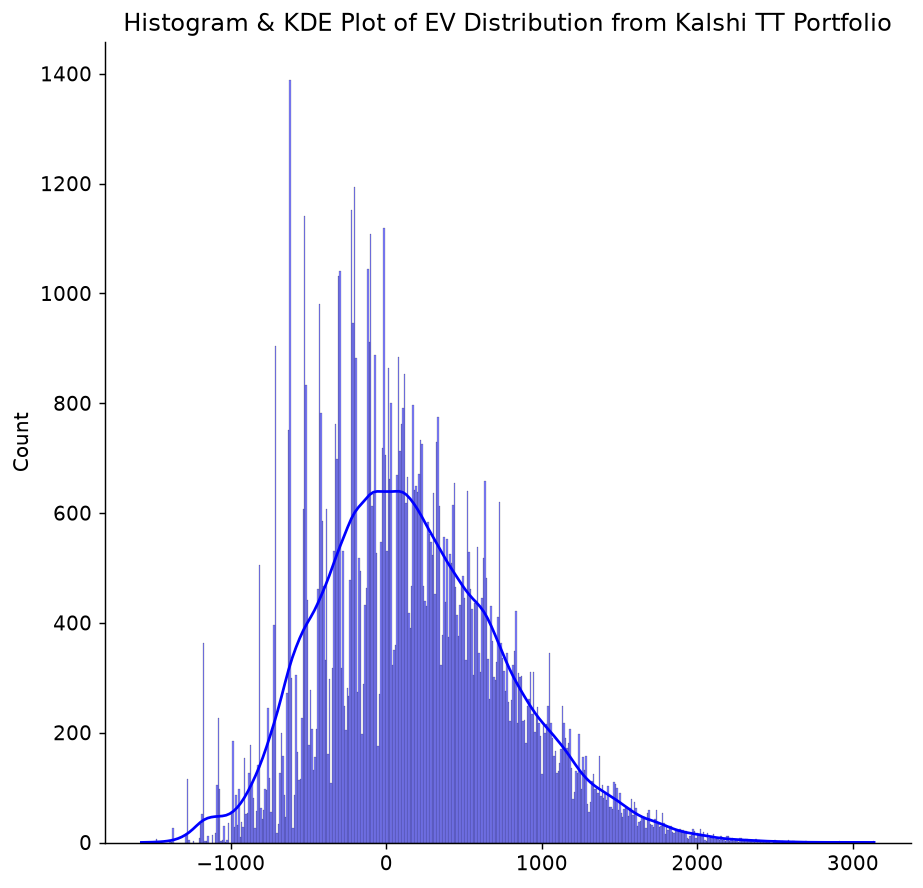

In [9]:
from bootstrap_mc_kalshi import (
    load_and_prepare, build_player_pool,
    build_portfolio, run_portfolio_mc, pnl_summary,
)

df, p_participate, app_counts = load_and_prepare(
    cut_players=['Magnus Carlsen'],
    attendance_model='gradient_boost'
)
players, p_play, hist_pcts, hist_wts = build_player_pool(df, p_participate, app_counts)
portfolio = build_portfolio(df_tt, players, PLAYER_TO_USERNAMES)
pnl = run_portfolio_mc(players, p_play, hist_pcts, hist_wts, portfolio, n_sims=100_000)
pnl_summary(pnl)


fig, ax = plt.subplots(1, 1, figsize=(8, 8))
        
sns.histplot(x=pnl, kde=True, ax=ax, color='blue', bins=500, label="No Magnus")

ax.set_title('Histogram & KDE Plot of EV Distribution from Kalshi TT Portfolio')

plt.show()
plt.close(fig)

In [1]:
dfp=pd.DataFrame()
for model in ['decay','gradient_boost','random_forest','logistic']:   
    df, p_participate, app_counts = load_and_prepare(
        cut_players=['Magnus Carlsen'],
        attendance_model=model
    )
    dfp[model] = p_participate
dfp = dfp.round(4).sort_values('decay',ascending=False)
dfp.head(100)

NameError: name 'pd' is not defined

In [ ]:
#!/usr/bin/env python3
"""
Titled Tuesday — Nonparametric Bootstrap Monte Carlo

For each simulated tournament:
  1. Draw the field: each player enters independently with probability p_participate.
  2. Each present player draws one rank_pct from their recency-weighted empirical
     distribution (pure bootstrap, no smoothing).
  3. Players are ranked by their drawn percentile (1.0 = winner, 0.0 = last).
  4. Top-N credits are tallied.

Two runs are compared: all eligible players vs. players with >= MIN_APPEARANCES.
"""

import time
import numpy as np
import pandas as pd

# ── Hyperparameters ───────────────────────────────────────────────────────────
DATA_CUTOFF         = '2022-02-01'
SKILL_DECAY         = 0.975   # per event: recency weight when bootstrap-sampling
PARTICIPATION_DECAY = 0.85   # per event: decay for P(player enters)
N_SIMS              = 30_000
N_VALUES            = [1, 3, 8]
MIN_P               = 0.000  # drop players too inactive to affect top-N results
MIN_APPEARANCES     = 0      # appearance threshold for the filtered run
CHUNK               = 10_000 # sims processed per memory chunk
SEED                = 42
CUT_PLAYERS = ['Magnus Carlsen']
KEEP_PLAYERS = []
# ── Data preparation ──────────────────────────────────────────────────────────
def load_and_prepare(cut_players = CUT_PLAYERS, keep_players= KEEP_PLAYERS):
    cut_users = [PLAYER_TO_USERNAMES[player][0] for player in cut_players]
    keep_users = [PLAYER_TO_USERNAMES[player][0] for player in keep_players]
    df = pd.read_csv('data/titled_tuesday_standings.csv', parse_dates=['date'])
    df = df[df['date'] >= '2022-02-08'].copy()

    # Keep best rank per player per event (handles rare duplicate entries)
    df = (
        df.sort_values('rank')
        .drop_duplicates(subset=['tournament_slug', 'username'], keep='first')
    )
    time_diff = (pd.Timestamp.now() - pd.to_datetime(df['date'])) // pd.Timedelta(weeks=1)
    N = (datetime.now()-datetime(2022,2,8))//pd.Timedelta(weeks=1)
    df['skill_w'] = SKILL_DECAY ** time_diff
    df['part_w']  = PARTICIPATION_DECAY ** time_diff

    # Rank percentile: 1.0 = winner, 0.0 = last place
    n_in_event     = df.groupby('tournament_slug')['username'].transform('count')
    df['rank_pct'] = 1.0 - (df['rank'].astype(float) - 1) / (n_in_event - 1)
    # Per-row weights for bootstrap sampling and participation

    # P(player enters next event): recency-weighted fraction of events attended
    Z_part        = sum(PARTICIPATION_DECAY ** k for k in range(N))
    p_participate = (df.groupby('username')['part_w'].sum() / Z_part).rename('p_participate')
    p_participate[p_participate.index.isin(cut_users)] = 0.0
    p_participate[p_participate.index.isin(keep_users)] = 1.0
    app_counts    = df.groupby('username')['tournament_slug'].nunique().rename('appearances')
    print(f'  {N} events | {df["username"].nunique():,} unique players '
        f'| {df["date"].min().date()} to {df["date"].max().date()}')
    return df, p_participate, app_counts


def build_player_pool(df, p_participate, app_counts, min_appearances=0):
    """Return arrays needed for simulation, filtered to eligible players."""
    eligible = p_participate[p_participate >= MIN_P].index
    if min_appearances > 0:
        eligible = eligible.intersection(app_counts[app_counts >= min_appearances].index)

    players = list(eligible)
    p_play  = p_participate.loc[players].to_numpy(dtype=np.float64)

    # Per-player empirical distributions: rank_pct values + normalised skill weights
    grp = df.groupby('username')
    hist_pcts, hist_wts = [], []
    for u in players:
        g   = grp.get_group(u)
        pct = g['rank_pct'].to_numpy(dtype=np.float32)
        w   = g['skill_w'].to_numpy(dtype=np.float64, copy=True)
        w  /= w.sum()
        hist_pcts.append(pct)
        hist_wts.append(w)

    return players, p_play, hist_pcts, hist_wts


# ── Simulation ────────────────────────────────────────────────────────────────

def run_simulation(players, p_play, hist_pcts, hist_wts,
                   n_sims=N_SIMS, n_values=N_VALUES, chunk=CHUNK, seed=SEED):
    rng   = np.random.default_rng()
    n     = len(players)
    max_N = max(n_values)

    plays_ct = np.zeros(n, dtype=np.int64)
    topn_ct  = {k: np.zeros(n, dtype=np.int64) for k in n_values}

    t0 = time.time()
    for start in range(0, n_sims, chunk):
        c = min(chunk, n_sims - start)

        # Draw one rank_pct per player per sim from their weighted empirical distribution
        scores = np.empty((c, n), dtype=np.float32)
        for i in range(n):
            idx = rng.choice(len(hist_pcts[i]), size=c, p=hist_wts[i], replace=True)
            scores[:, i] = hist_pcts[i][idx]

        # Draw field presence; mask absent players out of the ranking
        present = rng.random((c, n)) < p_play
        plays_ct += present.sum(axis=0)
        scores[~present] = -np.inf

        # Find top-max_N players per sim via partial sort, then rank the winners
        part  = np.argpartition(-scores, min(max_N, n - 1), axis=1)[:, :max_N]
        row   = np.arange(c)[:, None]
        order = part[row, np.argsort(-scores[row, part], axis=1)]  # shape (c, max_N)

        for k in n_values:
            top_k = order[:, :k]                          # shape (c, k)
            valid = scores[row, top_k] > -np.inf          # exclude if field < k players
            np.add.at(topn_ct[k], top_k[valid], 1)

        # print(f'  {start + c:>7,} / {n_sims:,}  ({time.time() - t0:.1f}s)')

    return plays_ct, topn_ct


# ── Output ────────────────────────────────────────────────────────────────────

def build_results(players, p_play, plays_ct, topn_ct, n_sims, n_values=N_VALUES):
    rows = {'p_participate': p_play}
    for k in n_values:
        with np.errstate(invalid='ignore', divide='ignore'):
            cond = np.where(plays_ct > 0, topn_ct[k] / plays_ct, 0.0)
        rows[f'P_top{k}_given_play'] = cond
        rows[f'P_top{k}']           = topn_ct[k] / n_sims
        rows[f'ip_adv_top{k}'] = cond / (topn_ct[k] / n_sims)
    return pd.DataFrame(rows, index=pd.Index(players, name='username'))


def print_top(results, sort_col, n=20, n_values=N_VALUES):
    cols = ['p_participate'] + [
        c for k in n_values for c in (f'P_top{k}_given_play', f'P_top{k}')
    ]
    print(results.nlargest(n, sort_col)[cols].to_string(float_format=lambda x: f'{x:.4f}'))

CUT_PLAYERS = ['Magnus Carlsen']
N_SIMS = 10_000

df, p_participate, app_counts = load_and_prepare(CUT_PLAYERS)
players, p_play, hist_pcts, hist_wts = build_player_pool(
    df, p_participate, app_counts, min_appearances=0
)

print(f'Pool: {len(players):,} players | simulating {N_SIMS:,} tournaments...')
plays_ct, topn_ct = run_simulation(players, p_play, hist_pcts, hist_wts, n_sims = N_SIMS)
results = build_results(players, p_play, plays_ct, topn_ct, n_sims= N_SIMS)

  230 events | 8,817 unique players | 2022-02-08 to 2026-07-07
Pool: 8,817 players | simulating 10,000 tournaments...


In [ ]:
TOP_N = [1, 3, 8]

def topN_pct(df_player, n):
    _sum = df_player['skill_coeff'].sum()
    topn_sum = df_player[df_player['rank']<=n]['skill_coeff'].sum()
    return topn_sum/_sum

df_player_est = (df_standings.groupby('username')['attendance_coeff'].sum() / ATTENDANCE_SUM).round(5).to_frame(name='attendance')

for n in TOP_N:
    results = (df_standings.groupby('username').apply(topN_pct, n=n)).round(5)
    df_player_est[f'top_{n}_when_play'] = results
    df_player_est[f'top_{n}_chance'] = results*df_player_est['attendance']
    df_player_est[f'top_{n}_chance']/=(df_player_est[f'top_{n}_chance'].sum()/n)

display(df_player_est.sort_values('top_1_chance', ascending=False))

,attendance,top_1_when_play,top_1_chance,top_3_when_play,top_3_chance,top_8_when_play,top_8_chance
username,,,,,,,
Hikaru,0.85853,0.14295,0.119104,0.34674,0.276995,0.57983,0.452254
MagnusCarlsen,0.32149,0.27218,0.084920,0.45200,0.135213,0.63692,0.186028
Polish_fighter3000,0.78707,0.09438,0.072091,0.22762,0.166700,0.40714,0.291127
mishanick,0.96957,0.06902,0.064944,0.17046,0.153785,0.42247,0.372135
DenLaz,0.80239,0.07404,0.057655,0.24072,0.179726,0.45496,0.331654
...,...,...,...,...,...,...,...
zeitnotakrobat,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000
zemogibax,0.00303,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000
zenitushka,0.00007,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000


In [17]:
def sanity_check(player_name, user=False, n=8, margin=.33):
    username = player_name
    if not user:
        username = PLAYER_TO_USERNAMES[player_name][0]
    player_results = results.loc[username]
    fair_odds = player_results[f'P_top{n}'].item()
    if_plays = player_results[f'P_top{n}_given_play'].item()
    yes_price = fair_odds*(1-margin)
    no_price = ((1-fair_odds)*(1-margin))
    print(
        f'P({n}): {np.round(fair_odds*100,2).item()}', 
        f'YES Price: {np.round(yes_price*100,2).item()} ({margin} margin)',
        f'NO Price: {np.round(no_price*100,2).item()} ({margin} margin)',
        f'P({n}) If Plays: {np.round(if_plays*100,2).item()}',
            sep='\n')
    sanity_check = df_standings[df_standings['username']==(username)]
    display(sanity_check.tail(20))
sanity_check('03revilo', user=True)

P(8): 0.0
YES Price: 0.0 (0.33 margin)
NO Price: 67.0 (0.33 margin)
P(8) If Plays: 0.0


,date,tournament_slug,session,rank,username,title,country,rating,score,tie_break,wins,draws,byes
19057,2022-08-23,late-titled-tuesday-blitz-august-23-2022-3337865,late,95,03revilo,FM,Germany,2448,5.5,24.00,5.0,1.0,0.0
24406,2022-10-11,late-titled-tuesday-blitz-october-11-2022-3459196,late,271,03revilo,FM,Germany,2448,2.0,1.00,2.0,0.0,0.0
32804,2022-12-27,early-titled-tuesday-blitz-december-27-2022-3663540,early,110,03revilo,FM,Germany,2448,5.5,24.75,5.0,1.0,0.0
48516,2023-05-02,late-titled-tuesday-blitz-may-02-2023-4002920,late,133,03revilo,FM,Germany,2448,5.0,53.00,3.0,4.0,0.0
50430,2023-05-16,late-titled-tuesday-blitz-may-16-2023-4020318,late,169,03revilo,FM,Germany,2448,4.5,41.50,4.0,1.0,0.0
51672,2023-05-23,late-titled-tuesday-blitz-may-23-2023-4033934,late,382,03revilo,FM,Germany,2448,2.0,28.00,1.0,2.0,0.0
58570,2023-07-11,early-titled-tuesday-blitz-july-11-2023-4158385,early,199,03revilo,FM,Germany,2448,5.0,47.00,5.0,0.0,0.0
59584,2023-07-18,early-titled-tuesday-blitz-july-18-2023-4171497,early,253,03revilo,FM,Germany,2448,4.0,12.00,4.0,0.0,0.0
60768,2023-07-25,early-titled-tuesday-blitz-july-25-2023-4185047,early,463,03revilo,FM,Germany,2448,2.5,26.00,2.0,1.0,0.0
61768,2023-08-01,early-titled-tuesday-blitz-august-01-2023-4198579,early,458,03revilo,FM,Germany,2448,3.0,26.50,2.0,2.0,0.0


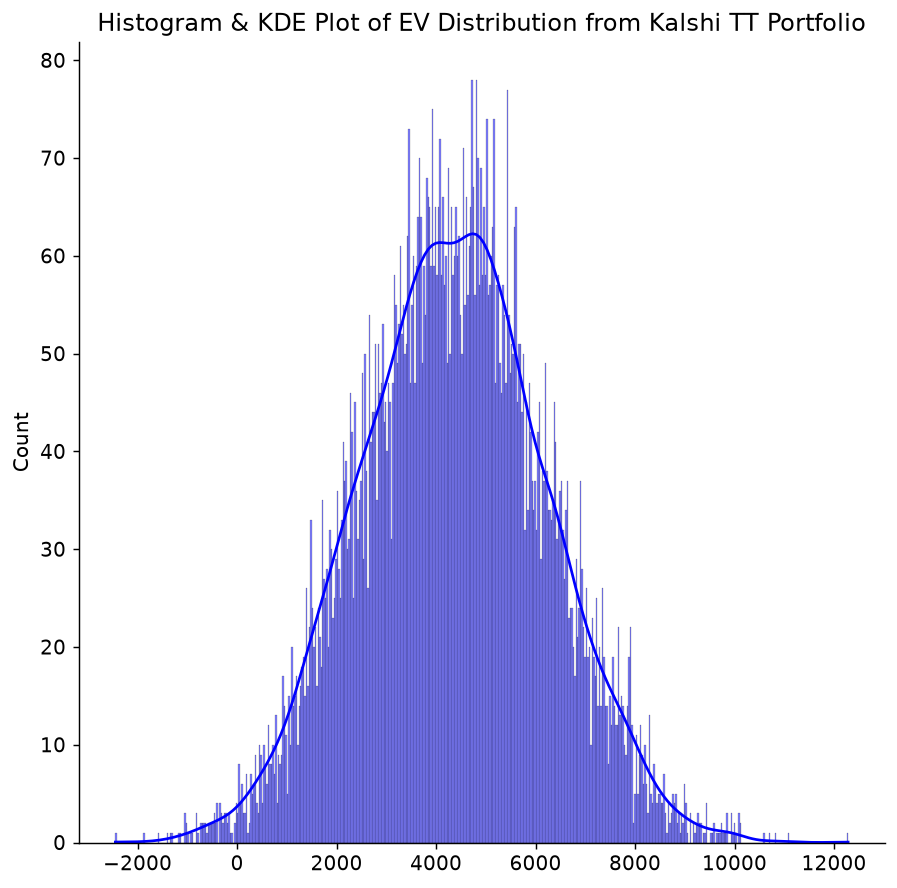

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
        
sns.histplot(x=[np.sum(np.random.choice(pnl,(10,))) for _ in range (10000)], kde=True, ax=ax, color='blue', bins=500)

ax.set_title('Histogram & KDE Plot of EV Distribution from Kalshi TT Portfolio')

plt.show()
plt.close(fig)

In [ ]:
from bootstrap_mc_kalshi import compute_hedge_correlations, show_best_hedges

df_corr, pnl = compute_hedge_correlations(
    players, p_play, hist_pcts, hist_wts, portfolio,
    n_values=[1, 3, 8], n_sims=10_000,
)

show_best_hedges(df_corr, top_k=20, username_to_player=USERNAME_TO_PLAYER)

   10,000 / 10,000  (4.4s)

── Best YES hedges (negative correlation with portfolio) ────────
                player  n  P(top N)  corr(YES, portfolio)
       Hikaru Nakamura  1    0.1030               -0.3558
       Hikaru Nakamura  3    0.2553               -0.3529
       Hikaru Nakamura  8    0.4654               -0.2580
       Fabiano Caruana  8    0.1991               -0.1512
       Fabiano Caruana  3    0.0898               -0.1022
       Christopher Yoo  8    0.2065               -0.0901
     Oleksandr Bortnyk  8    0.1979               -0.0794
Maxime Vachier-Lagrave  8    0.0347               -0.0774
       Christopher Yoo  3    0.0753               -0.0731
Maxime Vachier-Lagrave  3    0.0211               -0.0668
          Hans Niemann  8    0.2067               -0.0656
          Hans Niemann  3    0.0953               -0.0612
          Rasmus Svane  8    0.0805               -0.0598
     Oleksandr Bortnyk  3    0.0810               -0.0593
      Pranav Venkatesh  8    0.0673 